In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

# Set scanpy settings
sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [2]:
splice = ad.read_h5ad("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_INPUT/062025/per_celltype_20250629_115608/Inhibitory_Neurons/MOUSE_SPLICING_FOUNDATION_Inhibitory_Neurons_Anndata_ATSE_counts_with_waypoints_20250629_115608.h5ad")
ge = ad.read_h5ad("/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/model_train/CELL_TYPE_SPECIFIC/gene_expression/per_celltype_GE_20250628_161142/Inhibitory_Neurons/MOUSE_GE_FOUNDATION_Inhibitory_Neurons_with_embeddings_20250628_161142.h5ad")

In [3]:
splice.var["annotation_status"].value_counts()

annotation_status
both           23715
five_prime      2947
three_prime     2710
unannotated      267
Name: count, dtype: int64

In [4]:
assert all(splice.obs["cell_id"].values == ge.obs["cell_id"].values), "Cell IDs are not in the same order"


In [5]:
ge.X = ge.layers["log_norm"]

# Recompute PCA on the new X
sc.pp.pca(ge, n_comps=50)  # or however many components you want

# Now neighbors and UMAP use updated PCA
sc.pp.neighbors(ge, use_rep='X_pca')
sc.tl.umap(ge)
sc.tl.leiden(ge, resolution=1.0)  # or other resolution

computing PCA
    with n_comps=50
    finished (0:01:16)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:01:20)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:27)
running Leiden clustering
    finished: found 26 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:20)


In [6]:
# Compute neighbors and Leiden on splicing data
splice.X = splice.layers["junc_ratio"]
sc.pp.pca(splice, n_comps=30)
sc.pp.neighbors(splice, use_rep="X_pca")
sc.tl.umap(splice)
sc.tl.leiden(splice, resolution=1.0)

computing PCA
    with n_comps=30
    finished (0:06:24)
computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:07)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:28)
running Leiden clustering
    finished: found 11 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:28)


In [7]:
# Then transfer labels as above
ge.obs["leiden_splicing"] = splice.obs["leiden"].values
splice.obs["leiden_expression"] = ge.obs["leiden"].values

In [8]:
assert all(splice.obs["cell_id"].values == ge.obs["cell_id"].values), "Cell IDs are not in the same order"

In [12]:
splice

AnnData object with n_obs × n_vars = 16159 × 29639
    obs: 'cell_id_index', 'age', 'cell_ontology_class', 'mouse.id', 'sex', 'subtissue', 'tissue', 'dataset', 'cell_name', 'cell_id', 'cell_clean', 'broad_cell_type', 'seqtech', 'AgingScore_unweighted', 'AgingScore_pos', 'AgingScore_neg', 'leiden', 'leiden_expression'
    var: 'junction_id', 'event_id', 'splice_motif', 'annotation_status', 'gene_name', 'gene_id', 'num_junctions', 'position_off_5_prime', 'position_off_3_prime', 'CountJuncs', 'old_junction_id_index', 'non_zero_count_cells', 'non_zero_cell_prop', 'mean_expression', 'annotation_status_score', 'expression_score', 'cv_score', 'junction_id_index'
    uns: 'atse_filter_stats', 'pca_explained_variance_ratio', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'leiden_expression_colors', 'subtissue_colors', 'sex_colors'
    obsm: 'X_pca', 'X_umap', 'phi_init_30_waypoints'
    varm: 'psi_init_30_waypoints', 'PCs'
    layers: 'cell_by_cluster_matrix', 'cell_by_junction_matrix',

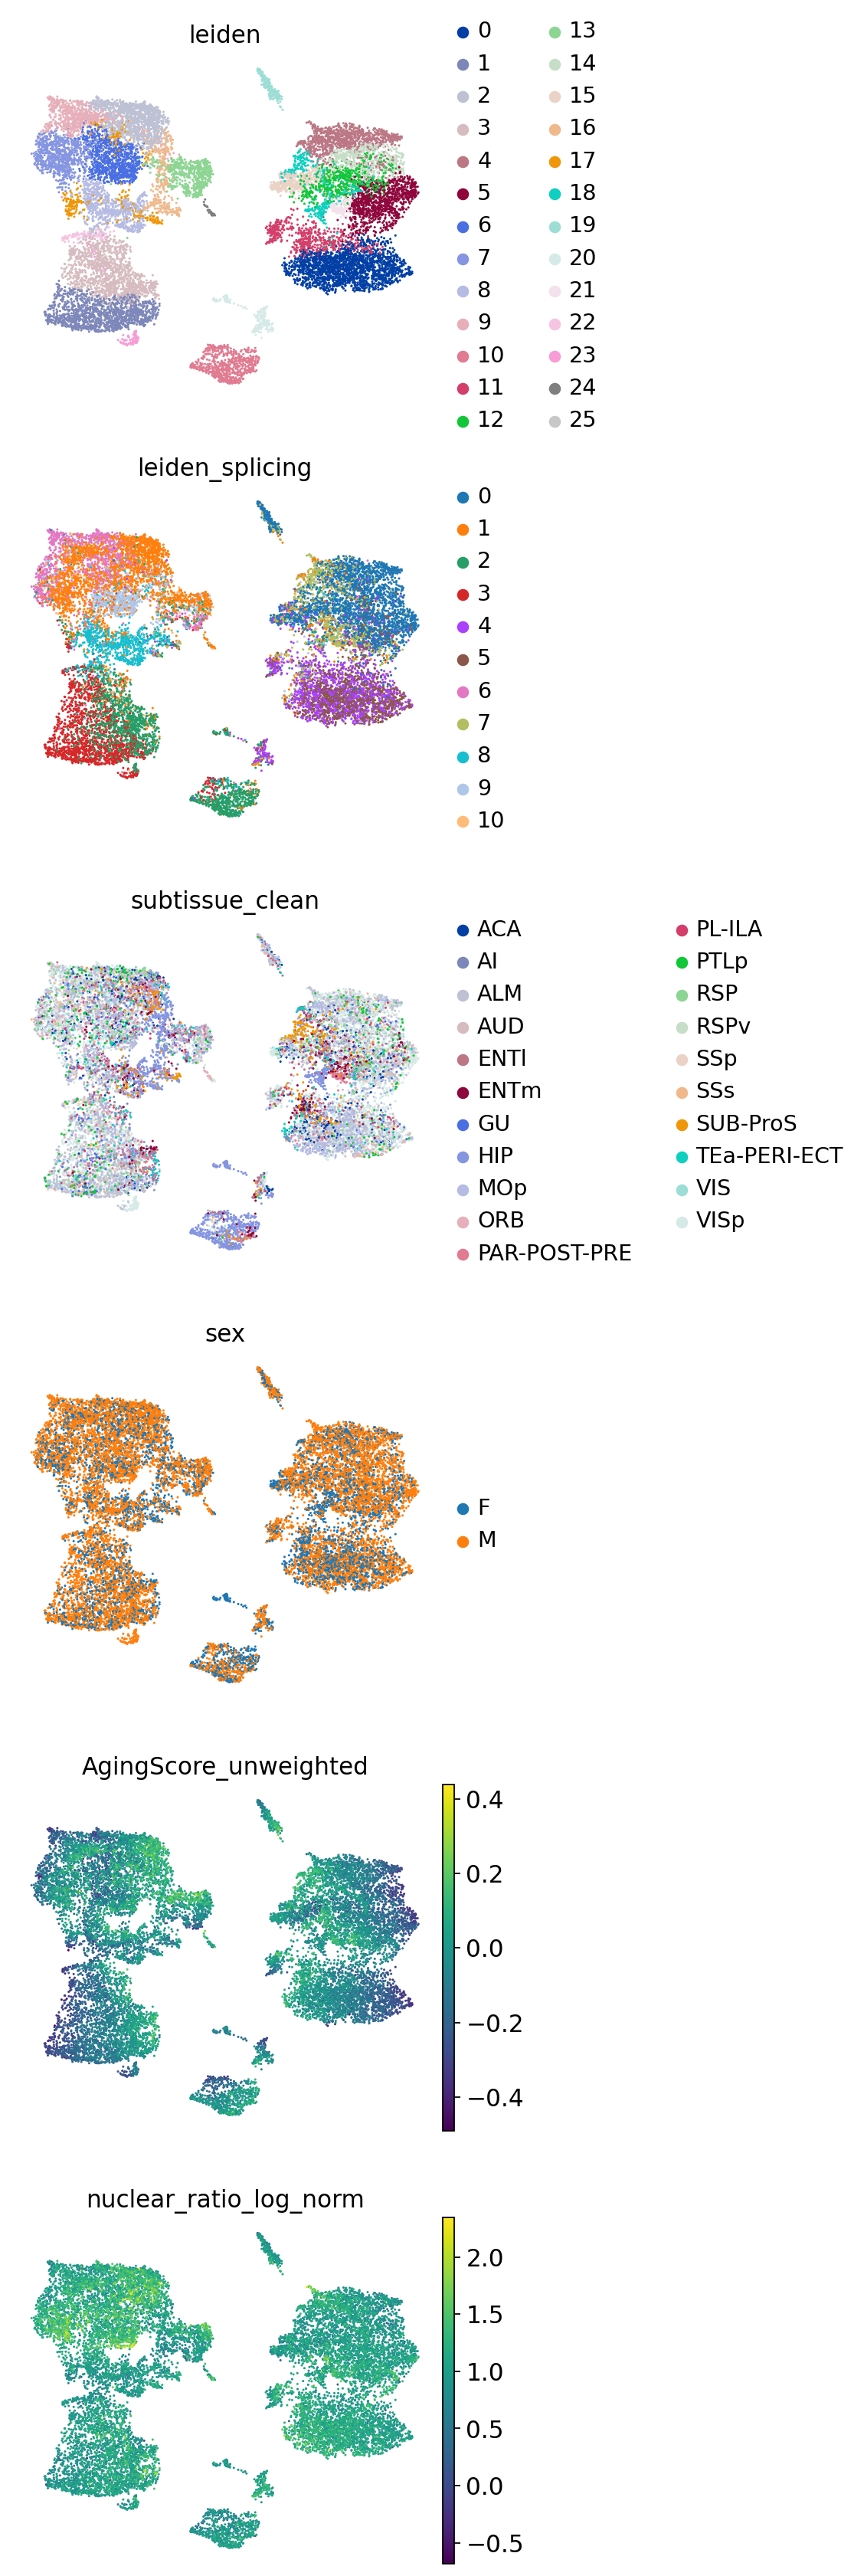

In [9]:
sc.pl.umap(
    ge,
    color=["leiden", "leiden_splicing", "subtissue_clean", "sex", "AgingScore_unweighted", "nuclear_ratio_log_norm"] ,
    frameon=False, 
    ncols=1
)


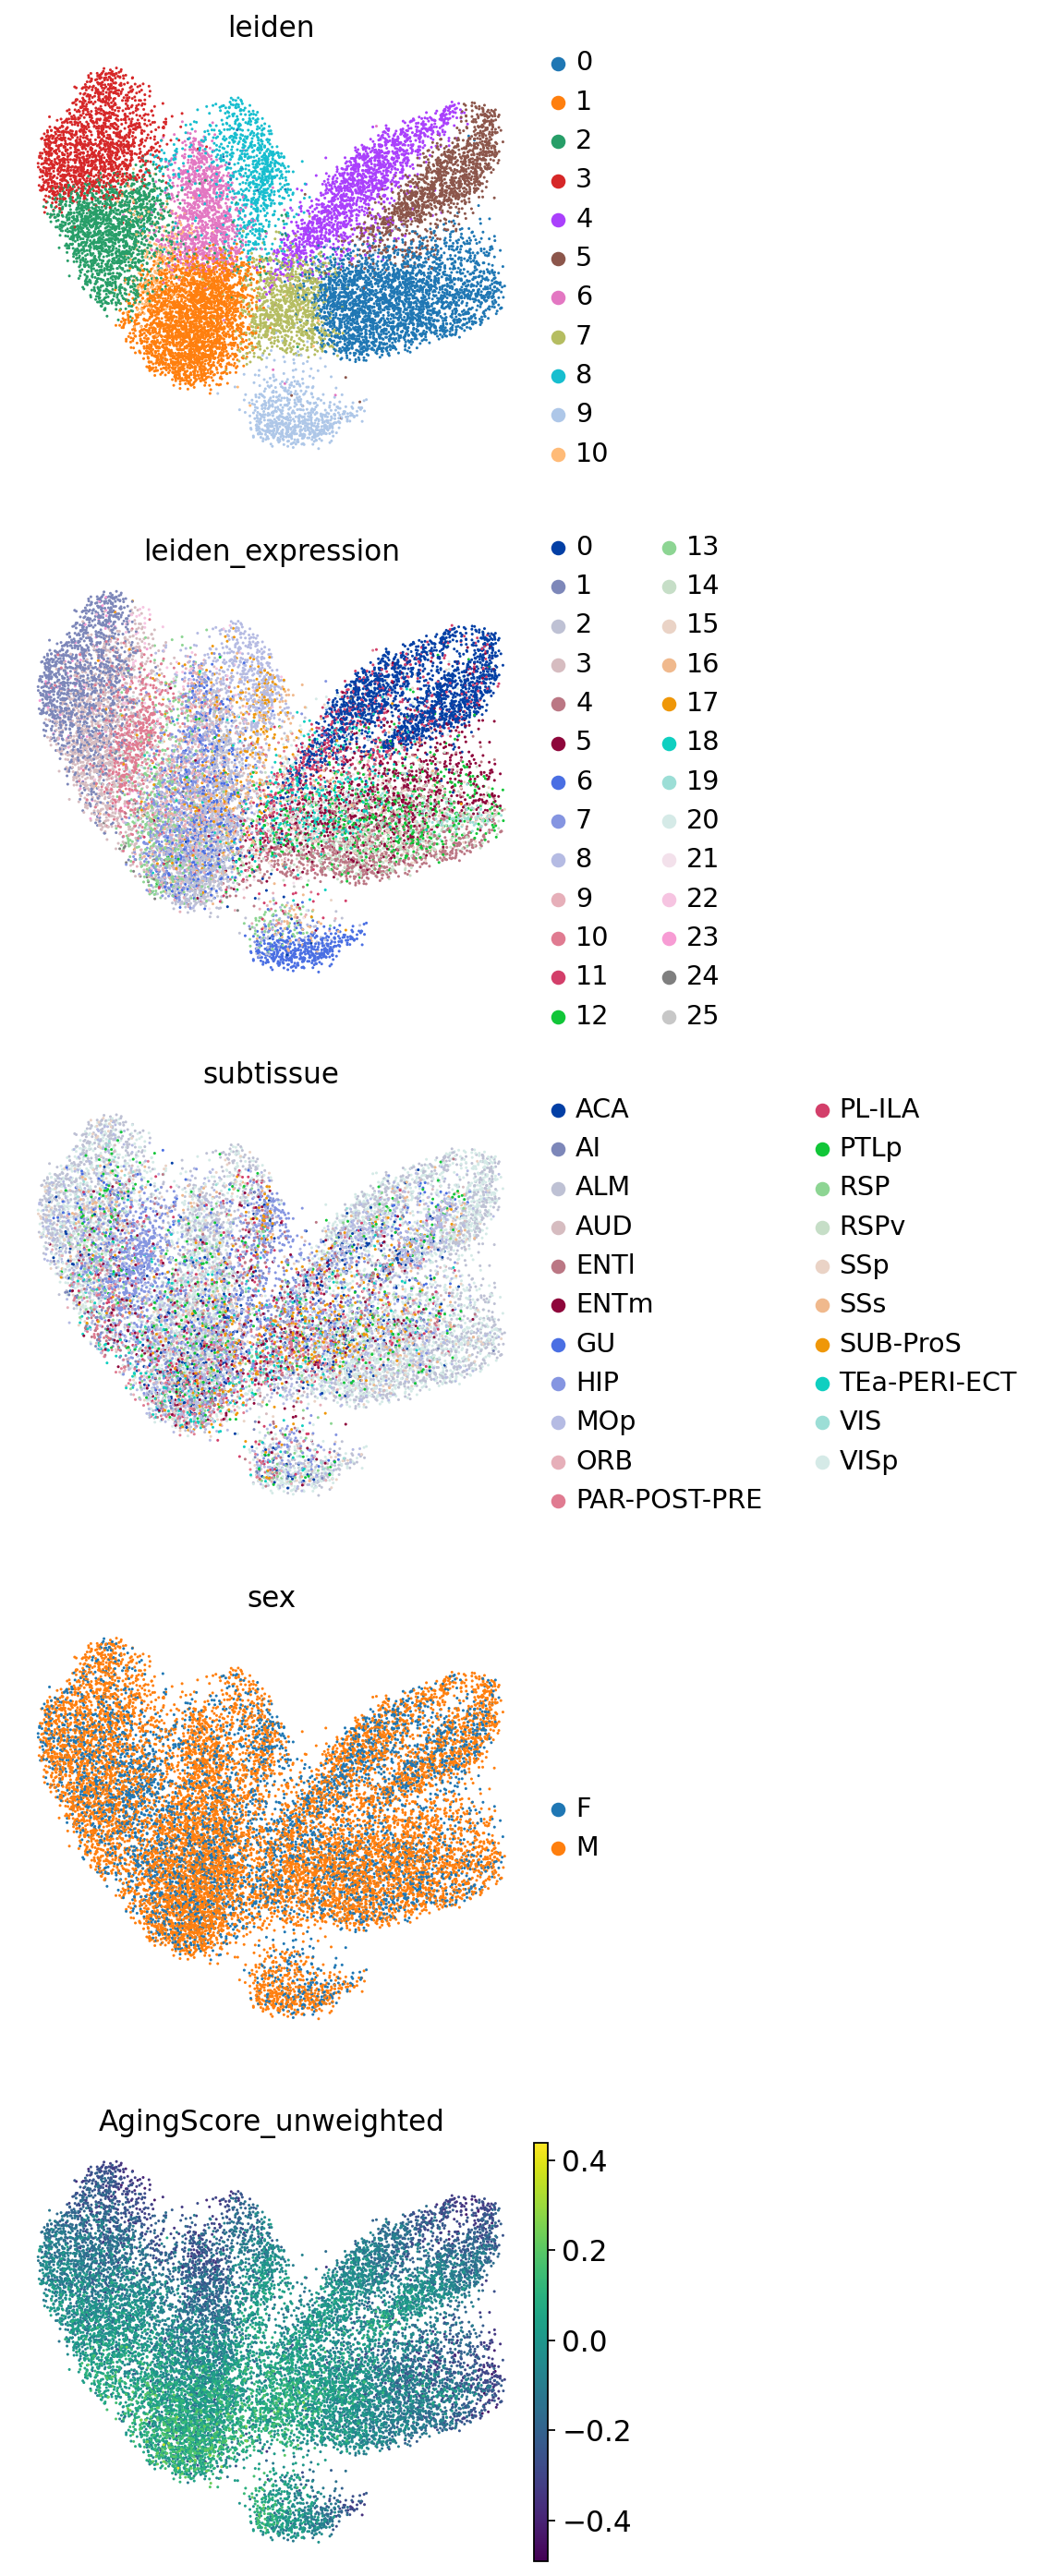

In [10]:
sc.pl.umap(
    splice,
    color=["leiden", "leiden_expression", "subtissue", "sex", "AgingScore_unweighted"] ,
    frameon=False, 
    ncols=1
)
